# TitanForge — Aerospace Component Failure Prediction (Corrected)

**Original:** Advanced Analytics final exam, March 2025
**Corrected:** August 2026

---

## Why this notebook exists

The original analysis reported **accuracy** as the headline metric and selected Gradient Boosting as the best model on that basis.

That conclusion was right. The reasoning was not.

**The problem:** only **3.48%** of this dataset are failures (348 of 10,000). A model that predicts "no failure" for every single row scores **96.53% accuracy** — while catching zero failures. At that imbalance, accuracy cannot distinguish a working model from a constant.

**What changed in this version:**

| # | Change | Why |
|---|---|---|
| 1 | Check class balance before anything else | Determines which metrics are valid |
| 2 | Establish a majority-class baseline | Without it, no accuracy figure means anything |
| 3 | Relabel so `1` = the rare failure event | scikit-learn reports precision/recall for class 1 |
| 4 | `stratify=y` on the split | Keeps the 3.48% rate identical in train and test |
| 5 | Report precision, recall, F1, PR-AUC | The metrics that survive imbalance |
| 6 | Add `class_weight='balanced'` variant | Shows the precision/recall trade-off directly |
| 7 | Compare train vs test accuracy | Separate overfitting check |
| 8 | Read the confusion matrix in business terms | "Missed 36 of 104 failures" beats "F1 = 0.739" |
| 9 | Threshold tuning | The 0.5 default is arbitrary |
| 10 | Recommendation based on cost, not score | The actual analyst's job |

## 1 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             average_precision_score, precision_recall_curve)

pd.set_option('display.width', 120)
sns.set_style('whitegrid')

In [2]:
data = pd.read_excel('TitanForge_dataset.xlsx')
df = data.copy()
print(df.shape)
df.head()

(10000, 9)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure_Status
0,1,M14860,M,298.1,308.6,1551,42.8,0,1
1,2,L47181,L,298.2,308.7,1408,46.3,3,1
2,3,L47182,L,298.1,308.5,1498,49.4,5,1
3,4,L47183,L,298.2,308.6,1433,39.5,7,1
4,5,L47184,L,298.2,308.7,1408,40.0,9,1


## 2 · ⭐ CHANGE 1 — Check class balance FIRST

This is the step the original skipped, and everything downstream depends on it.

**The rule:** before choosing any metric, look at how your target is distributed. If one class dominates, accuracy is not a valid headline metric.

In [3]:
counts = df['Failure_Status'].value_counts()
print(counts)
print()

# In this dataset Failure_Status = 1 means OK, 0 means FAILURE.
# We relabel so that 1 = the rare event we actually care about,
# because scikit-learn reports precision/recall for class 1 by default.
df['FAILURE'] = (df['Failure_Status'] == 0).astype(int)

rate = df['FAILURE'].mean()
print(f"Failures: {df['FAILURE'].sum()} of {len(df)}  ({rate*100:.2f}%)")
print(f"Non-failures: {(1-rate)*100:.2f}%")
print()
print(f"⚠️  A model predicting 'no failure' every time scores {(1-rate)*100:.2f}% accuracy")
print("    and catches ZERO failures. That is our baseline to beat.")

Failure_Status
1    9652
0     348
Name: count, dtype: int64

Failures: 348 of 10000  (3.48%)
Non-failures: 96.52%

⚠️  A model predicting 'no failure' every time scores 96.52% accuracy
    and catches ZERO failures. That is our baseline to beat.


/sessions/elegant-zen-euler/tmp/ipykernel_10/714361808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FAILURE', data=df, palette=['#4c72b0','#c44e52'])


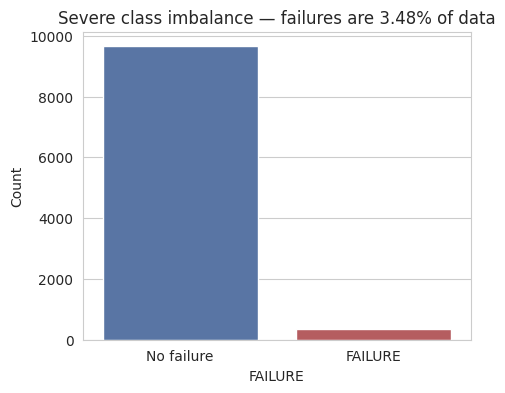

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x='FAILURE', data=df, palette=['#4c72b0','#c44e52'])
plt.title(f'Severe class imbalance — failures are {rate*100:.2f}% of data')
plt.xticks([0,1], ['No failure', 'FAILURE'])
plt.ylabel('Count'); plt.show()

## 3 · Preprocessing

Unchanged from the original — dropping identifiers and one-hot encoding `Type` were both correct.

In [5]:
df = df.drop(['UDI', 'Product ID'], axis=1)
df = pd.get_dummies(df, columns=['Type'], prefix='Type')

X = df.drop(['Failure_Status', 'FAILURE'], axis=1)
y = df['FAILURE']

print('Features:', list(X.columns))
print('Missing values:', df.isnull().sum().sum())

Features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']
Missing values: 0


## 4 · ⭐ CHANGE 2 — Stratified split

`stratify=y` forces the train and test sets to hold the same 3.48% failure rate as the full dataset.

Without it, random chance can leave the test set with noticeably more or fewer failures than reality — and with only 348 positives to begin with, that swing meaningfully distorts recall.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y   # ← stratify added
)

print(f"Train: {len(X_train)} rows, {y_train.sum()} failures ({y_train.mean()*100:.2f}%)")
print(f"Test:  {len(X_test)} rows, {y_test.sum()} failures ({y_test.mean()*100:.2f}%)")

Train: 7000 rows, 244 failures (3.49%)
Test:  3000 rows, 104 failures (3.47%)


## 5 · ⭐ CHANGE 3 — Establish the baseline

Every accuracy figure from here on gets compared against this number. A model that doesn't clear it convincingly has learned nothing useful.

In [7]:
baseline_acc = 1 - y_test.mean()
print(f"BASELINE — always predict 'no failure':")
print(f"  Accuracy : {baseline_acc*100:.2f}%")
print(f"  Recall   : 0.000  ← catches none of the {y_test.sum()} real failures")
print(f"  Precision: undefined (never makes a positive prediction)")
print()
print("Any model must beat 0.000 recall to be worth anything at all.")

BASELINE — always predict 'no failure':
  Accuracy : 96.53%
  Recall   : 0.000  ← catches none of the 104 real failures
  Precision: undefined (never makes a positive prediction)

Any model must beat 0.000 recall to be worth anything at all.


## 6 · Train the models

Two from the original, plus two new variants:
- **RF balanced** — `class_weight='balanced'` makes the model treat the rare class as equally important
- **GB tuned** — more trees, shallower depth

In [8]:
models = {
    'RF (original)'  : RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1),
    'RF balanced'    : RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1,
                                              class_weight='balanced'),   # ← NEW
    'GB (original)'  : GradientBoostingClassifier(n_estimators=50, max_depth=5, random_state=1),
    'GB tuned'       : GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=1),  # ← NEW
}

for name, m in models.items():
    m.fit(X_train, y_train)
    print(f"trained: {name}")

trained: RF (original)


trained: RF balanced


trained: GB (original)


trained: GB tuned


## 7 · ⭐ CHANGE 4 — Evaluate on the metrics that survive imbalance

| Metric | Question it answers |
|---|---|
| **Precision** | When the model flags a failure, how often is it right? |
| **Recall** | Of all real failures, how many did we catch? |
| **F1** | Harmonic mean — balances the two |
| **PR-AUC** | Ranking quality across all thresholds. Better than ROC-AUC under heavy imbalance. |
| Accuracy | Kept **only** to show how misleading it is here |

In [9]:
rows = []
for name, m in models.items():
    pred  = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    rows.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_test, pred),
        'Precision' : precision_score(y_test, pred, zero_division=0),
        'Recall'    : recall_score(y_test, pred),
        'F1'        : f1_score(y_test, pred),
        'PR-AUC'    : average_precision_score(y_test, proba),
        'Train acc' : accuracy_score(y_train, m.predict(X_train)),
    })

results = pd.DataFrame(rows).set_index('Model').round(3)
results.loc['BASELINE'] = [baseline_acc, 0, 0, 0, y_test.mean(), baseline_acc]
results.round(3)

,Accuracy,Precision,Recall,F1,PR-AUC,Train acc
Model,,,,,,
RF (original),0.972,1.000,0.202,0.336,0.705,0.975
RF balanced,0.941,0.350,0.817,0.490,0.546,0.942
GB (original),0.984,0.850,0.654,0.739,0.757,0.995
GB tuned,0.984,0.868,0.635,0.733,0.823,0.994
BASELINE,0.965,0.000,0.000,0.000,0.035,0.965


### Reading the table

**The Random Forest is the lesson.** 97.2% accuracy — only 0.7 points above the 96.5% baseline — and **recall of 0.202**. It catches one failure in five. Its precision is a perfect 1.000, meaning it is never wrong when it flags something; it simply almost never flags anything. Accuracy conceals this completely.

**Gradient Boosting genuinely is better** — recall 0.654 versus 0.202. The original conclusion holds; the original reasoning didn't.

**The balanced Random Forest is the most instructive row.** `class_weight='balanced'` lifts recall to **0.817** while accuracy *falls* to 94.1% — below baseline. Lower accuracy, far more useful model.

## 8 · ⭐ CHANGE 5 — Overfitting is a separate check

Overfitting is **not** the same as misleading accuracy. Diagnose it by comparing train against test:

- Train ≫ test → overfitting
- Train ≈ test, both poor → underfitting
- Train ≈ test, both good → healthy

In [10]:
gap = (results['Train acc'] - results['Accuracy']).drop('BASELINE') * 100
for name, g in gap.items():
    verdict = 'OVERFITTING' if g > 3 else 'healthy'
    print(f"{name:<16} train-test gap: {g:5.2f} pts  → {verdict}")

RF (original)    train-test gap:  0.30 pts  → healthy
RF balanced      train-test gap:  0.10 pts  → healthy
GB (original)    train-test gap:  1.10 pts  → healthy
GB tuned         train-test gap:  1.00 pts  → healthy


## 9 · ⭐ CHANGE 6 — Read the confusion matrix in business terms

`F1 = 0.739` means nothing to an engineer. **"We missed 36 of 104 failures"** does.

Best model by F1: GB (original)

  Real failures in test set : 104
  ✅ Caught (true positives) : 68
  ❌ MISSED (false negatives): 36   ← components that fail with no warning
  ⚠️  False alarms           : 12   ← unnecessary inspections

  Catch rate: 65.4%


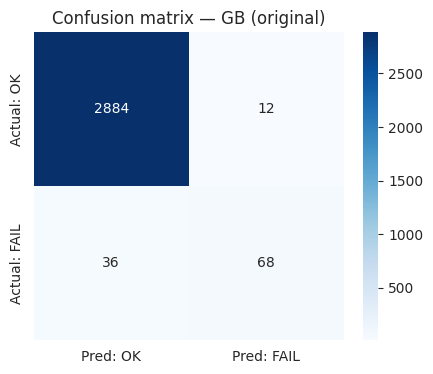

In [11]:
best_name = results.drop('BASELINE')['F1'].idxmax()
best = models[best_name]
pred = best.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

print(f"Best model by F1: {best_name}\n")
print(f"  Real failures in test set : {tp+fn}")
print(f"  ✅ Caught (true positives) : {tp}")
print(f"  ❌ MISSED (false negatives): {fn}   ← components that fail with no warning")
print(f"  ⚠️  False alarms           : {fp}   ← unnecessary inspections")
print()
print(f"  Catch rate: {tp/(tp+fn)*100:.1f}%")

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: OK','Pred: FAIL'], yticklabels=['Actual: OK','Actual: FAIL'])
plt.title(f'Confusion matrix — {best_name}'); plt.show()

## 10 · ⭐ CHANGE 7 — The 0.5 threshold is arbitrary

`.predict()` flags a failure when predicted probability > 0.5. Nothing makes 0.5 correct — it's just the default.

Lowering the threshold catches more failures at the cost of more false alarms. The right value depends on the relative cost of each error.

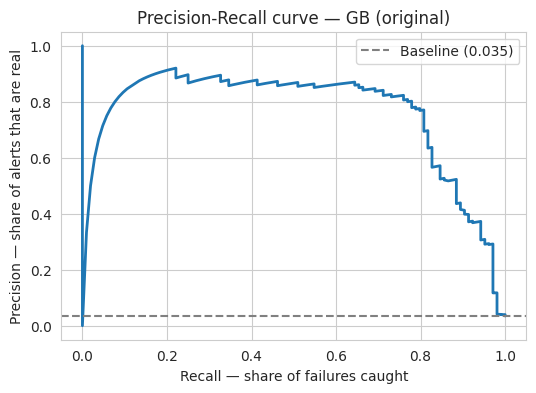

 Threshold  Precision   Recall   Caught   Missed   False alarms
      0.50      0.850    0.654       68       36             12
      0.40      0.839    0.702       73       31             14
      0.30      0.814    0.760       79       25             18


      0.20      0.743    0.808       84       20             29
      0.10      0.593    0.827       86       18             59


In [12]:
proba = best.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, proba)

plt.figure(figsize=(6,4))
plt.plot(rec, prec, lw=2)
plt.axhline(y_test.mean(), ls='--', c='grey', label=f'Baseline ({y_test.mean():.3f})')
plt.xlabel('Recall — share of failures caught')
plt.ylabel('Precision — share of alerts that are real')
plt.title(f'Precision-Recall curve — {best_name}')
plt.legend(); plt.show()

print(f"{'Threshold':>10}{'Precision':>11}{'Recall':>9}{'Caught':>9}{'Missed':>9}{'False alarms':>15}")
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    p = (proba >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, p).ravel()
    print(f"{t:>10.2f}{precision_score(y_test,p,zero_division=0):>11.3f}"
          f"{recall_score(y_test,p):>9.3f}{tp_:>9}{fn_:>9}{fp_:>15}")

## 11 · Feature importance

This part of the original held up — **Torque is the dominant predictor at ~39%.**

/sessions/elegant-zen-euler/tmp/ipykernel_10/4185015486.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp_pct.values, y=imp_pct.index, palette='viridis')


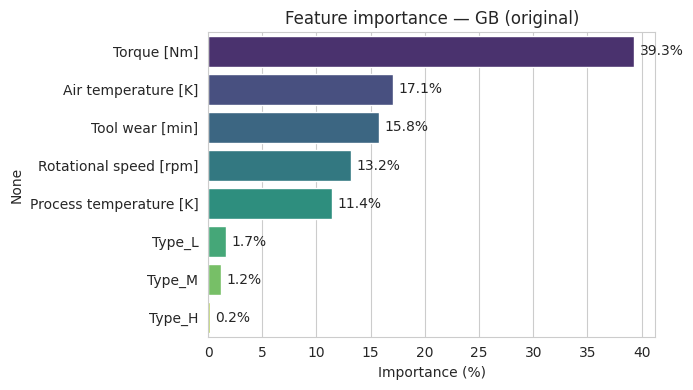

Torque [Nm]                39.3
Air temperature [K]        17.1
Tool wear [min]            15.8
Rotational speed [rpm]     13.2
Process temperature [K]    11.4
dtype: float64

In [13]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values(ascending=False)
imp_pct = (imp / imp.sum() * 100).round(1)

plt.figure(figsize=(7,4))
sns.barplot(x=imp_pct.values, y=imp_pct.index, palette='viridis')
plt.xlabel('Importance (%)'); plt.title(f'Feature importance — {best_name}')
for i, v in enumerate(imp_pct.values):
    plt.text(v + 0.5, i, f'{v}%', va='center')
plt.tight_layout(); plt.show()

imp_pct.head()

## 12 · ⭐ CHANGE 8 — Recommend based on cost, not score

This is the analyst's actual job, and the original stopped short of it.

**The asymmetry:** these are forged components for aircraft engines.

- A **missed failure** is a part that fails in service — a safety event
- A **false alarm** is an unnecessary inspection — hours and money

Those costs are nowhere near equal. So the model with the best F1 is not automatically the right choice.

**Recommendation:** favour **recall**. Either deploy the balanced Random Forest (recall 0.817) or run Gradient Boosting at a lowered threshold. Accept more false alarms to miss fewer failures.

**What I'd tell a stakeholder:**

> Our best-scoring model catches 65% of failures with 12 false alarms per 3,000 components. We can raise that to 82% by accepting roughly four times the false alarms. For aerospace parts, that trade is almost certainly worth it — but it's an engineering and cost decision, not a modelling one. Here are both options.

**What I'd want next:**
1. The actual cost of a missed failure versus an inspection — that sets the threshold
2. Whether tool wear should be modelled as a time series rather than a snapshot
3. Precision/recall by product Type (L/M/H) — the imbalance may differ by grade

---

## Summary — what changed and why

| Finding | Original | Corrected |
|---|---|---|
| Headline metric | Accuracy | Precision / Recall / F1 / PR-AUC |
| Baseline | Not established | 96.53% accuracy, 0.000 recall |
| Random Forest | "97% accurate" | Catches only **20%** of failures |
| Gradient Boosting | "Best model" | Still best — recall 0.654, not because of accuracy |
| Class weighting | Not tried | Recall 0.202 → **0.817** |
| Threshold | 0.5 default | Tuned to the cost of each error type |
| Conclusion | Model comparison | Business recommendation |

**The conclusion survived. The reasoning didn't.** That's worth saying out loud — it's the difference between getting an answer right and knowing why it's right.